In [1]:
import os
os.chdir("..")
os.chdir("..")

from ducks.utils.utils import notebook_line_magic
notebook_line_magic()

Line Magic Set


In [25]:
import numpy as np

from ducks.utils.plotting_utils import (
    plot_reward_distribution_by_episode_quantile, plot_obs_distribution_by_episode_quantile,
    plot_action_distribution_by_episode_quantile
    )#, plot_dist_from_sample
from ducks.utils.training_utils import (
    load_minari_dataset, get_filtered_episodes_from_minari_dataset, 
    get_rewards_by_episode_quantile, get_dataloader_from_episodes,
    get_actions_by_episode_quantile, get_obs_by_episode_quantile
)

Dataset Name:  mujoco/hopper/simple-v0
Observation space: Box(-inf, inf, (11,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)
Total episodes: 1952
Total steps: 999206





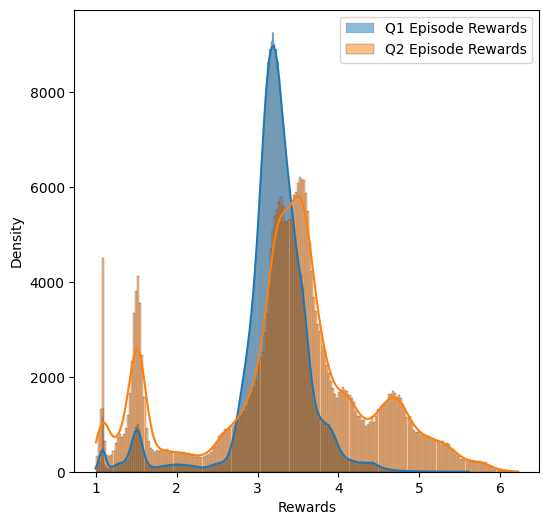

In [21]:
minari_dataset = load_minari_dataset()
filtered_episode_datasets = get_filtered_episodes_from_minari_dataset(minari_dataset) #use these filtered episodes to create dataloaders
episode_rewards_by_quantile = get_rewards_by_episode_quantile(filtered_episode_datasets)
episode_actions_by_quantile = get_actions_by_episode_quantile(filtered_episode_datasets)
episode_obs_by_quantile = get_obs_by_episode_quantile(filtered_episode_datasets)
plot_reward_distribution_by_episode_quantile(episode_rewards_by_quantile)

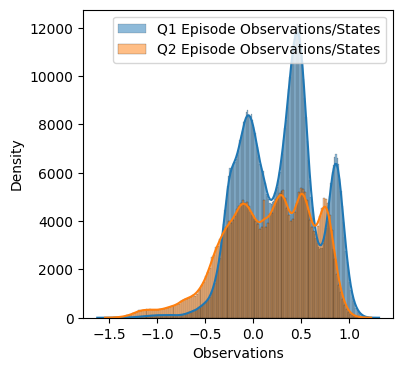

In [26]:
plot_obs_distribution_by_episode_quantile(episode_obs_by_quantile)

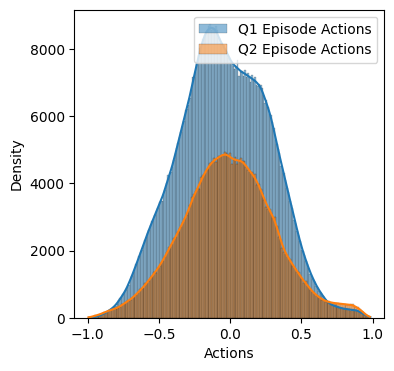

In [27]:
plot_action_distribution_by_episode_quantile(episode_actions_by_quantile)

In [45]:
dataloaders = get_dataloader_from_episodes(filtered_episode_datasets)
sample_from_batch = next(iter(dataloaders[0]))['observations'][:1] #get one observation
reward_sample_from_batch = next(iter(dataloaders[0]))['rewards'][:1] #get one observation
action_sample_from_batch = next(iter(dataloaders[0]))['actions'][:1] #get one observation

In [46]:
# torch.movedim(sample_from_batch, 0, 1).shape
sample_from_batch.shape, reward_sample_from_batch.shape, action_sample_from_batch.shape

(torch.Size([1, 1024, 11]), torch.Size([1, 1000]), torch.Size([1, 1024, 3]))

- How to combine observations, actions, and rewards to train a diffusion model? maybe trees?

In [36]:
# each episode is made of a variable number of steps. Each step is made of a (State, Action, Reward) tuple.
# import numpy as np
# obs = []
# for ep in minari_dataset.iterate_episodes(episode_indices=[1,2,3,4,7]):
#     print(ep.rewards.shape)

# torch.as_tensor(ep.observations).unsqueeze(0).shape

In [47]:
def plot_dist_from_sample(sample):
    import seaborn as sns
    import matplotlib.pyplot as plt
    sns.displot(sample.cpu().numpy(), kind="hist", height=2, aspect=1.5)
    plt.show()

In [9]:
# for ep in filtered_episode_datasets[1].iterate_episodes(episode_indices=[4,7]):
#     print(ep.observations)

### Training Pipeline

In [48]:
import torch
from torchvision import transforms
from diffusers import DDPMScheduler
import matplotlib.pyplot as plt
import seaborn as sns
device="cuda"

T = 1000
noise_scheduler = DDPMScheduler(num_train_timesteps=T)

##add noise to a sample of 8 observations and visualize 1 out of 8
timesteps = torch.linspace(0, T-1, 8).long().to(device) #T-1 would be 999. 0-999 is 1000 steps
noise = torch.randn_like(sample_from_batch)
noisy_xb = noise_scheduler.add_noise(sample_from_batch, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)

Noisy X shape torch.Size([8, 1024, 11])


In [49]:
# noisy_x.squeeze().numpy().mean(axis=0).T#.shape

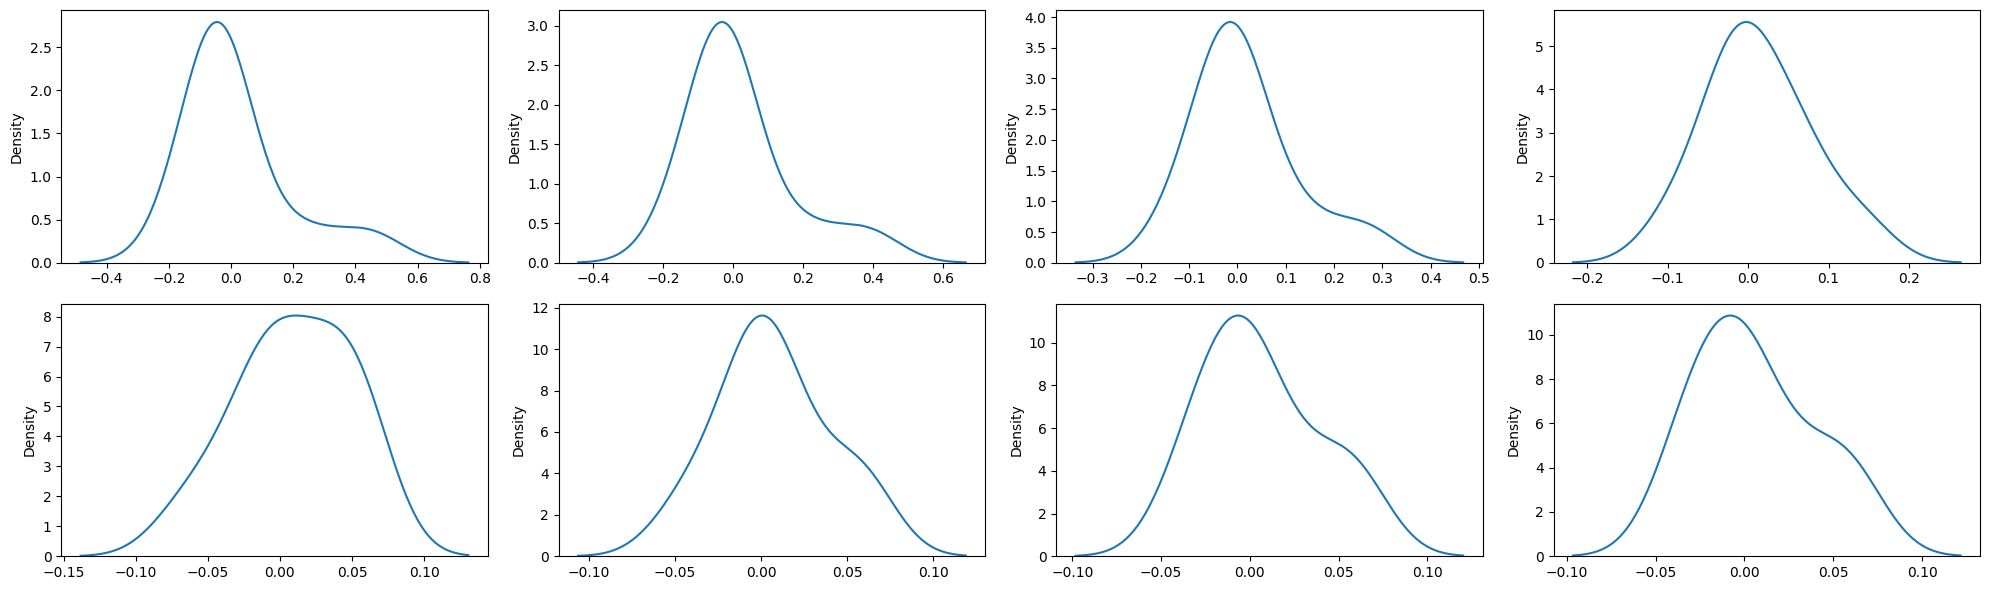

In [50]:
num_plots = 10
stepsize = int(T/num_plots)

fig, axs = plt.subplots(2, len(noisy_xb)//2, figsize=(20,6))
axs = axs.flatten()
for ax, noisy_x in zip(axs, noisy_xb):
    # plot_dist_from_sample(x)
    sns.kdeplot(noisy_x.squeeze().numpy().mean(axis=0), ax=ax, legend=False)
plt.tight_layout()
plt.show()

In [53]:
# sample_from_batch.shape[-1]
# x.shape


# noisy_xb.shape
x = noisy_xb.permute(0, 2, 1)   # [8, 11, 1001]
t = torch.randint(0, 1024, (x.shape[0],), device=device)  # example timesteps
x.shape, t.shape

# with torch.no_grad():
#     model_prediction = model(x.to(device), t).sample
# model_prediction.shape

(torch.Size([8, 11, 1024]), torch.Size([8]))

In [62]:
from ducks.models.diffusion_train import train_diffusion

models = train_diffusion()

Dataset Name:  mujoco/hopper/simple-v0
Observation space: Box(-inf, inf, (11,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)
Total episodes: 1952
Total steps: 999206
Epoch:50, loss: 0.5720870953339797
Epoch:100, loss: 0.5580663818579453
Epoch:150, loss: 0.5543724871598757
Epoch:200, loss: 0.5414339762467605
Epoch:250, loss: 0.5387185491048373
Epoch:300, loss: 0.5415645379286546
Epoch:350, loss: 0.5395595041605142
Epoch:400, loss: 0.5333157663161938
Epoch:450, loss: 0.5325235013778393
Epoch:500, loss: 0.528467969252513
Epoch:50, loss: 0.5368598964479234
Epoch:100, loss: 0.522069114777777
Epoch:150, loss: 0.5225606560707092
Epoch:200, loss: 0.5163959314425787
Epoch:250, loss: 0.5216190665960312
Epoch:300, loss: 0.5189782314830356
Epoch:350, loss: 0.5131736132833693
Epoch:400, loss: 0.5120790443486638
Epoch:450, loss: 0.5127258367008634
Epoch:500, loss: 0.51356417271826


In [61]:
with torch.no_grad():
    model_prediction = models[0](x.to(device), t).sample
model_prediction.shape

torch.Size([8, 11, 1024])

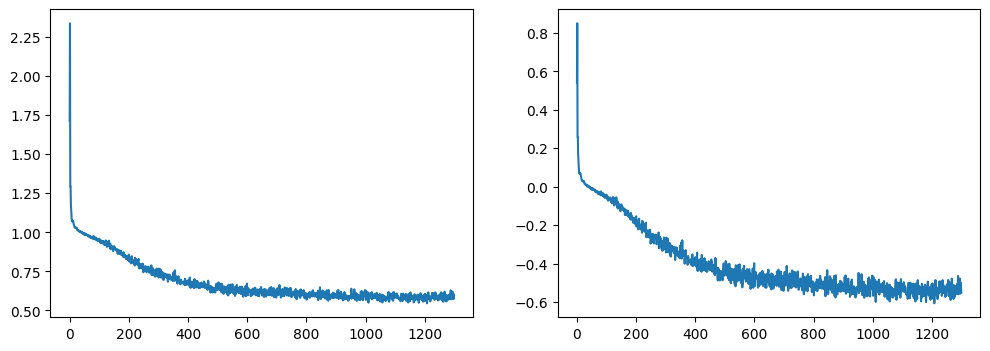

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

In [42]:
@torch.no_grad()
def sample_1d_ddpm(unet, scheduler, batch_size=1, length=None, device="cuda"):
    unet.eval()

    C = unet.config.in_channels
    L = length if length is not None else unet.config.sample_size

    # IMPORTANT: 3D noise for 1D UNet
    x = torch.randn((batch_size, C, L), device=device, dtype=torch.float32)

    scheduler.set_timesteps(scheduler.config.num_train_timesteps, device=device)

    for t in scheduler.timesteps:
        # UNet1DModel returns an object with .sample
        noise_pred = unet(x, t).sample
        step = scheduler.step(noise_pred, t, x)
        x = step.prev_sample

    return x  # [B, C, L]


L_pad = 1024  # pick a pad-safe length (32/64 multiple)
x = sample_1d_ddpm(model.to("cuda"), noise_scheduler, batch_size=1, length=L_pad)

# crop back if you need 1001
x = x[..., :1001]  # [1, C, 1001]

# if you want [B, 1, T, F] format:
x = x.permute(0, 2, 1).unsqueeze(1)  # [1, 1, 1001, 11]

In [43]:
x[0].squeeze().shape

torch.Size([1001, 11])

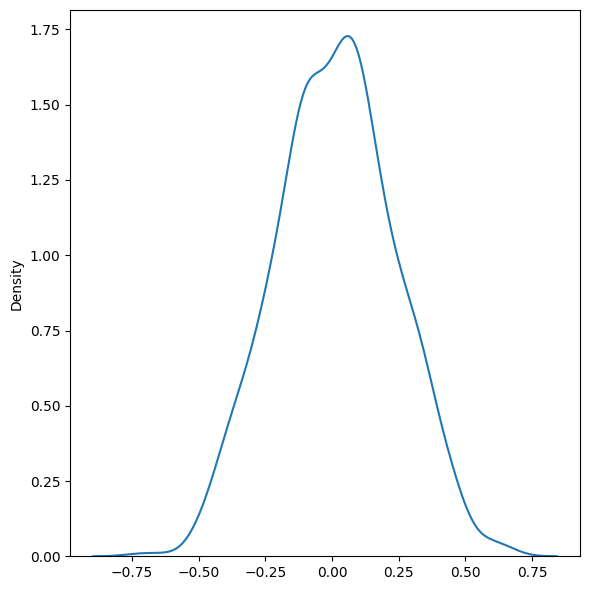

In [67]:
sns.kdeplot(x[0].squeeze().cpu().numpy().mean(axis=1), legend=False)
plt.tight_layout()
plt.show()

## Next Steps:
- Remove padding from the generated samples to get the max episode length for each episode_dataset.
- Create a custom loss to incorporate actions and rewards
- Modularize code and trigger model training and data generation

- Create a training dataset by combining state, action, rewards into a single dataset in the order in which they were experienced.

1. Train a diffusion model for dataset containing episodes for each quantile
2. Interpolate the parameters for all trained models
3. Use the final interpolated model to generate new samples (state, actions, rewards)

Idea A:
---------------------
4. Train an offline agent using the newly generated data
5. Iteract with each environment (based on the dataset) using the trained agent

Idea B:
----------------------
4. Interact with the environment to get a state.
5. Measure similarity of the state with the states in the generated dataset.
6. Use the action from the most similar state with the highest reward.